# Guided Numeric Exploration — MCU & Marvel Media
_Ratings concordance, phase×universe economics, and cast popularity across Marvel titles_

***

**Programming Language:** Python in the Jupyter Notebook Environment

**Dataset:** [vanshkumar007/mcu-and-marvel-media-complete-dataset](https://www.kaggle.com/datasets/vanshkumar007/mcu-and-marvel-media-complete-dataset)

**Style counterpart:** [Guided Numeric and Text Exploration — E-Commerce](https://www.kaggle.com/code/nicapotato/guided-numeric-and-text-exploration-e-commerce)

**Code Navigation:** <br>
In the code, text after hashtags (`#`) are supportive explanations, not executed as code.

***


# Tables of Content:

**1. [Introduction](#Introduction)** <br>
**2. [Setup, Missingness & Parsing](#Setup)** <br>
**3. [Univariate Snapshot](#Univariate)** <br>
**4. [Ratings Concordance](#Ratings)** <br>
**5. [Phase × Universe & ROI](#PhaseROI)** <br>
**6. [Cast Popularity](#Cast)** <br>
**7. [Multivariate Association (RF)](#Association)** <br>
**8. [What It Means — Working Synthesis](#Synthesis)** <br>

# **1. Introduction:** <a id="Introduction"></a> <br>
Three linked tables: `marvel_master.csv` (161×50 primary), `marvel_ratings.csv` (long ratings by source), and `marvel_cast.csv` (cast popularity). Missingness is heavy — especially production/website (fully empty), TV episode fields, and many OMDb score fields. Empty production/website columns are dropped; other gaps are documented and analyses use complete cases where required.

ROI = `revenue_usd / budget_usd` where both are > 0.


# **2. Setup, Missingness & Parsing:** <a id="Setup"></a>


In [1]:
# General
import numpy as np
import pandas as pd
from pathlib import Path
import re

# Visualization
import matplotlib.pyplot as plt
import seaborn as sns
%matplotlib inline

# Scientific / modeling helpers
from IPython.display import display
from scipy import stats
from sklearn.ensemble import RandomForestClassifier, RandomForestRegressor
from sklearn.compose import ColumnTransformer
from sklearn.pipeline import Pipeline
from sklearn.preprocessing import OneHotEncoder, StandardScaler

import kagglehub

# Set Plot Theme (same family as the e-commerce guided notebook)
sns.set_palette([
    "#30a2da",
    "#fc4f30",
    "#e5ae38",
    "#6d904f",
    "#8b8b8b",
])
sns.set_theme(style="whitegrid")
plt.rcParams["figure.figsize"] = (11, 5)

# Warnings
import warnings
warnings.filterwarnings("ignore")

# Wide table inspection in Jupyter cell outputs
pd.set_option("display.max_columns", 999)
pd.set_option("display.width", 220)


**Code Explanation and Reasoning:** <br>
These packages fall into three buckets: *General*, *Visualization*, and *Scientific / modeling helpers*.

`pandas` / `numpy` hold the table; `matplotlib` / `seaborn` do the graphics; `scipy` and `sklearn` support light associational checks (correlations, RandomForest importances), not a production model. `kagglehub` resolves files both on Kaggle (`/kaggle/input/...`) and locally.

The five-color palette matches the guided e-commerce notebook so sequential plots feel like one continuous exploration.


In [2]:
# Read linked Marvel tables
KAGGLE_SLUG = "vanshkumar007/mcu-and-marvel-media-complete-dataset"
MASTER = "marvel_master.csv"
RATINGS = "marvel_ratings.csv"
CAST = "marvel_cast.csv"
EXPECTED_MASTER = [
    "id", "title", "year", "imdb_id", "type", "rated", "runtime_min", "genre", "director",
    "writer", "actors", "plot", "language", "country", "awards", "imdb_rating", "imdb_votes",
    "rt_score", "metacritic_score", "box_office_usd", "production", "website", "mcu_phase",
    "universe", "decade", "age_years", "is_animated", "is_tv_series", "is_mcu_canon",
    "tmdb_id", "tmdb_genres", "budget_usd", "revenue_usd", "tmdb_rating", "tmdb_votes",
    "popularity", "top5_cast", "directors", "producers", "composer", "tmdb_keywords",
    "collection_name", "poster_url", "production_countries", "spoken_languages",
    "episode_count", "season_count", "network", "status", "tagline",
]


def resolve_csv_path(basename: str) -> Path:
    kaggle_root = Path("/kaggle/input")
    if kaggle_root.exists():
        for p in kaggle_root.rglob(basename):
            return p
    local_data = Path("data") / basename
    if local_data.exists():
        return local_data
    root = Path(kagglehub.dataset_download(KAGGLE_SLUG))
    p = root / basename
    if not p.exists():
        hits = list(root.rglob(basename))
        assert hits, f"expected {basename} under {root}"
        p = hits[0]
    return p


master_path = resolve_csv_path(MASTER)
ratings_path = resolve_csv_path(RATINGS)
cast_path = resolve_csv_path(CAST)
print("Master:", master_path)
print("Ratings:", ratings_path)
print("Cast:", cast_path)

df = pd.read_csv(master_path, low_memory=False)
ratings = pd.read_csv(ratings_path, low_memory=False)
cast = pd.read_csv(cast_path, low_memory=False)

missing = set(EXPECTED_MASTER) - set(df.columns)
assert not missing, f"missing master columns: {sorted(missing)}"
assert len(df) == 161, f"expected 161 master rows, got {len(df)}"
assert df.shape[1] == 50, f"expected 50 master cols, got {df.shape[1]}"
assert {"title", "year", "source", "score"} <= set(ratings.columns)
assert {"title", "year", "actor_name", "popularity", "cast_order"} <= set(cast.columns)

# Document missingness before drops
null_rate = (df.isnull().mean().sort_values(ascending=False)).to_frame("null_rate")
display(null_rate.head(20).style.format({"null_rate": "{:.1%}"}))
assert df["production"].isna().all() and df["website"].isna().all(), "expected empty production/website"
df = df.drop(columns=["production", "website"])
print("Dropped empty columns: production, website")


def parse_pct(series: pd.Series) -> pd.Series:
    """Parse '82%' or numeric-like strings to float score on 0-100."""
    out = series.astype(str).str.replace("%", "", regex=False).str.strip()
    out = out.replace({"nan": np.nan, "None": np.nan, "": np.nan})
    return pd.to_numeric(out, errors="coerce")


def parse_metacritic(series: pd.Series) -> pd.Series:
    """Parse '63/100' or bare numbers to 0-100 float."""
    s = series.astype(str).str.strip()
    s = s.str.replace(r"/100$", "", regex=True)
    s = s.replace({"nan": np.nan, "None": np.nan, "": np.nan})
    return pd.to_numeric(s, errors="coerce")


df["rt_score_num"] = parse_pct(df["rt_score"])
df["metacritic_num"] = parse_metacritic(df["metacritic_score"])
df["imdb_rating"] = pd.to_numeric(df["imdb_rating"], errors="coerce")
df["tmdb_rating"] = pd.to_numeric(df["tmdb_rating"], errors="coerce")
df["budget_usd"] = pd.to_numeric(df["budget_usd"], errors="coerce")
df["revenue_usd"] = pd.to_numeric(df["revenue_usd"], errors="coerce")
df["roi"] = np.where(
    (df["budget_usd"] > 0) & (df["revenue_usd"] > 0),
    df["revenue_usd"] / df["budget_usd"],
    np.nan,
)

ratings["score_num"] = pd.to_numeric(ratings["score"], errors="coerce")

print("Master shape after drop:", df.shape)
print("Ratings:", ratings.shape, "| Cast:", cast.shape)
print("ROI complete cases (budget>0 & revenue>0):", int(df["roi"].notna().sum()))
display(df.sample(5, random_state=7))


Master: /kaggle/input/datasets/vanshkumar007/mcu-and-marvel-media-complete-dataset/marvel_master.csv
Ratings: /kaggle/input/datasets/vanshkumar007/mcu-and-marvel-media-complete-dataset/marvel_ratings.csv
Cast: /kaggle/input/datasets/vanshkumar007/mcu-and-marvel-media-complete-dataset/marvel_cast.csv


,null_rate
production,100.0%
website,100.0%
season_count,93.2%
network,93.2%
episode_count,93.2%
box_office_usd,55.9%
metacritic_score,55.3%
collection_name,55.3%
rt_score,51.6%
awards,47.2%


Dropped empty columns: production, website
Master shape after drop: (161, 51)
Ratings: (554, 5) | Cast: (1628, 9)
ROI complete cases (budget>0 & revenue>0): 75


,id,title,year,imdb_id,type,rated,runtime_min,genre,director,writer,actors,plot,language,country,awards,imdb_rating,imdb_votes,rt_score,metacritic_score,box_office_usd,mcu_phase,universe,decade,age_years,is_animated,is_tv_series,is_mcu_canon,tmdb_id,tmdb_genres,budget_usd,revenue_usd,tmdb_rating,tmdb_votes,popularity,top5_cast,directors,producers,composer,tmdb_keywords,collection_name,poster_url,production_countries,spoken_languages,episode_count,season_count,network,status,tagline,rt_score_num,metacritic_num,roi
88,89,Runaways (Season 1),2017,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,Non-MCU,MCU,2010s,8,0,0,1,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN
79,80,Iron Fist (Season 1),2017,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,Non-MCU,Netflix Marvel,2010s,8,0,0,0,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN
37,38,The Incredible Hulk,2008,tt0800080,movie,PG-13,112.0,"Action, Adventure, Sci-Fi",Louis Leterrier,"Zak Penn, Stan Lee, Jack Kirby","Edward Norton, Liv Tyler, Tim Roth","Bruce Banner, a scientist on the run from the ...","English, Portuguese, Spanish","United States, Canada, Japan",4 wins & 10 nominations total,6.6,"563,613",68%,61/100,134806913.0,Phase 1,MCU,2000s,17,0,0,1,1724.0,"Science Fiction, Action, Adventure",150000000.0,264770996.0,6.244,12723.0,12.6732,"Edward Norton, Liv Tyler, Tim Roth, William Hu...",Louis Leterrier,"Gale Anne Hurd, Kevin Feige, Avi Arad",Craig Armstrong,"new york city, rio de janeiro, superhero, base...",NaN,https://image.tmdb.org/t/p/w500/gKzYx79y0AQTL4...,United States of America,"Portuguese, Spanish, English",NaN,NaN,NaN,Released,You'll like him when he's angry.,68.0,61.0,1.76514
95,96,Cloak & Dagger (Season 1),2018,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,Non-MCU,MCU,2010s,7,0,0,1,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN
63,64,Daredevil (Season 1),2015,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,Non-MCU,Netflix Marvel,2010s,10,0,0,0,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN


**Code Explanation and Reasoning:** <br>
All three files resolve via the same kagglehub root. Empty `production`/`website` columns are asserted empty and dropped. `rt_score` (`82%`) and `metacritic_score` (`63/100`) are parsed to numeric; ROI is defined only on positive budget×revenue pairs.


In [3]:
print("Master null counts (top):")
display(df.isnull().sum().sort_values(ascending=False).head(15).to_frame("nulls"))
print("Ratings null score rate:", round(ratings["score_num"].isna().mean(), 3))
print("Type / universe / phase:")
display(df["type"].value_counts())
display(df["universe"].value_counts())
display(df["mcu_phase"].value_counts())


Master null counts (top):


,nulls
season_count,150
episode_count,150
network,150
box_office_usd,90
metacritic_score,89
metacritic_num,89
collection_name,89
roi,86
rt_score_num,83
rt_score,83


Ratings null score rate: 0.605
Type / universe / phase:


type
movie     101
series     13
Name: count, dtype: int64

universe
MCU                  88
Pre-MCU              27
Fox / X-Men          18
Sony / Spider-Man    15
Netflix Marvel       13
Name: count, dtype: int64

mcu_phase
Non-MCU      58
Pre-MCU      36
Phase 5/6    26
Phase 4      18
Phase 3      11
Phase 1       6
Phase 2       6
Name: count, dtype: int64

**Interpretation** <br>
Missingness is structural: TV episode fields empty for movies; OMDb scores sparse for newer/TV titles. Universe and MCU phase are the taxonomy axes for later ROI and ratings slices.


# **3. Univariate Snapshot:** <a id="Univariate"></a>


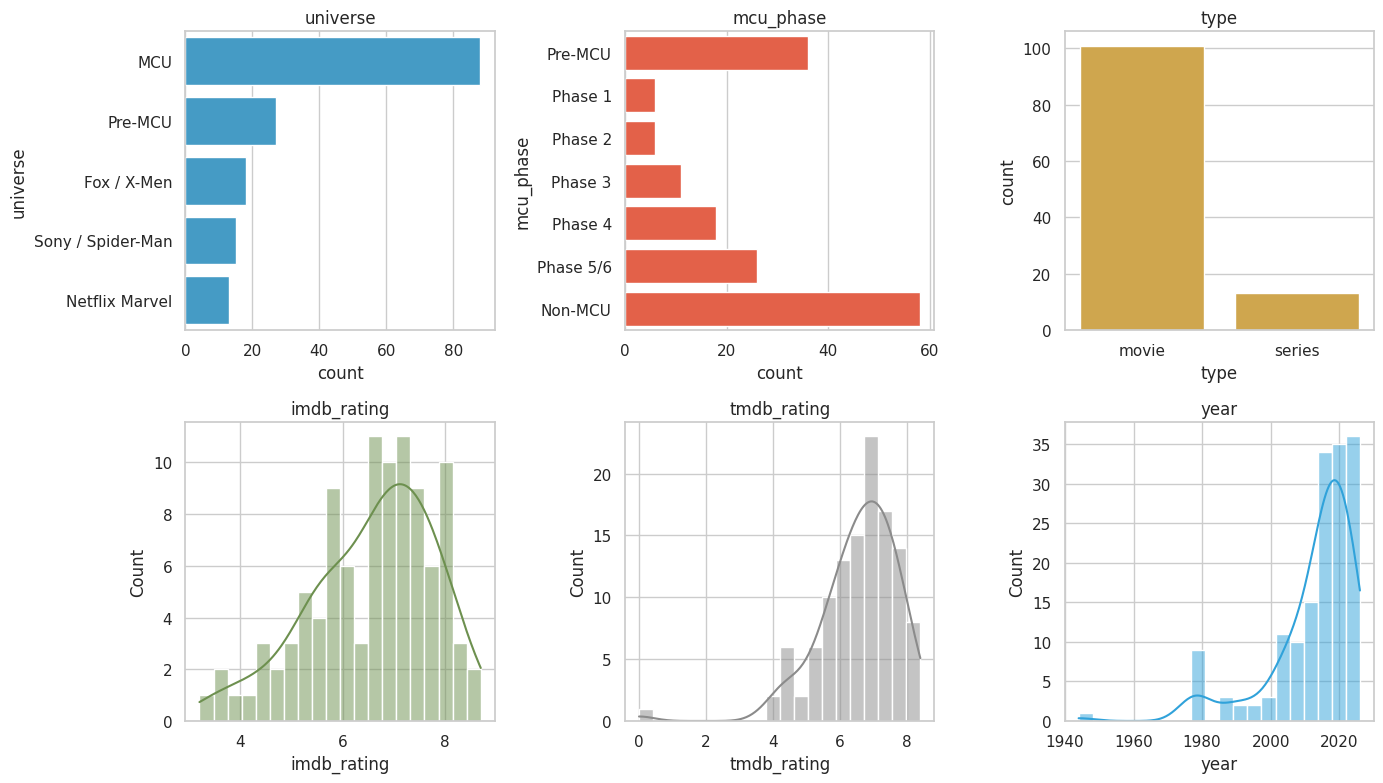

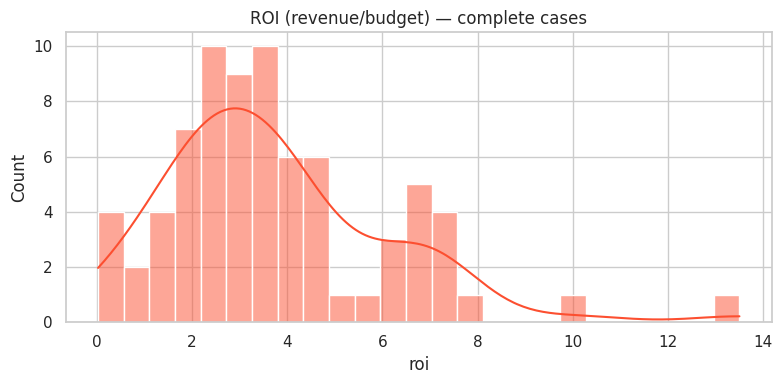

In [4]:
fig, axes = plt.subplots(2, 3, figsize=(14, 8))
axes = axes.ravel()
sns.countplot(data=df, y="universe", order=df["universe"].value_counts().index, ax=axes[0], color="#30a2da")
axes[0].set_title("universe")
phase_order = ["Pre-MCU", "Phase 1", "Phase 2", "Phase 3", "Phase 4", "Phase 5/6", "Non-MCU"]
phase_order = [p for p in phase_order if p in set(df["mcu_phase"])]
sns.countplot(data=df, y="mcu_phase", order=phase_order, ax=axes[1], color="#fc4f30")
axes[1].set_title("mcu_phase")
sns.countplot(data=df, x="type", ax=axes[2], color="#e5ae38")
axes[2].set_title("type")
for ax, col, color in [
    (axes[3], "imdb_rating", "#6d904f"),
    (axes[4], "tmdb_rating", "#8b8b8b"),
    (axes[5], "year", "#30a2da"),
]:
    sns.histplot(df[col].dropna(), bins=20, kde=True, ax=ax, color=color)
    ax.set_title(col)
plt.tight_layout()
plt.show()

fig, ax = plt.subplots(figsize=(8, 4))
sns.histplot(df.loc[df["roi"].notna(), "roi"], bins=25, kde=True, ax=ax, color="#fc4f30")
ax.set_title("ROI (revenue/budget) — complete cases")
plt.tight_layout()
plt.show()


**Interpretation** <br>
MCU titles dominate; Non-MCU/Pre-MCU fill the rest. Rating histograms are on different scales/completeness — concordance comes next. ROI is right-skewed among complete cases.


# **4. Ratings Concordance:** <a id="Ratings"></a>


source,IMDb,TMDB
count,102.00,117.00
mean,6.56,6.55
std,1.22,1.19
min,3.20,0.00
25%,5.70,5.94
50%,6.75,6.74
75%,7.48,7.36
max,8.70,8.39


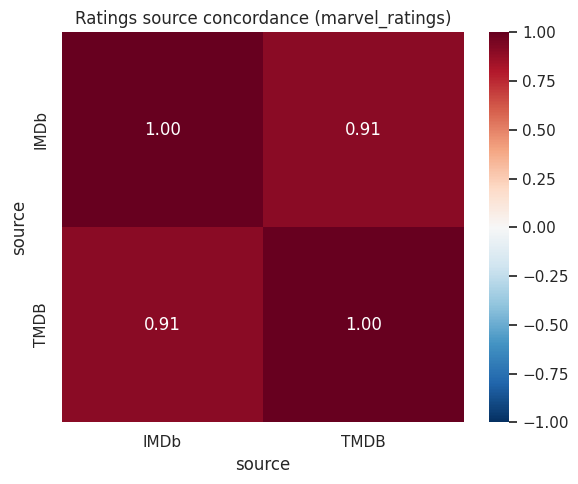

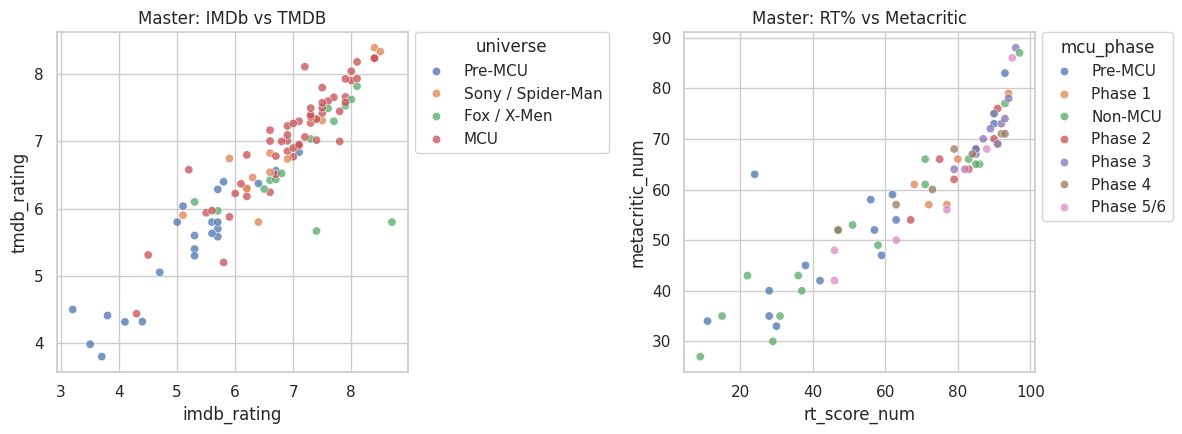

IMDb↔TMDB Pearson r=0.906, p=1.01e-38, n=101


In [5]:
# Wide ratings from marvel_ratings + master parsed scores
wide = ratings.pivot_table(index=["title", "year"], columns="source", values="score_num", aggfunc="first")
display(wide.describe().round(2))

# Pairwise complete-case correlations among sources present
src_cols = [c for c in ["IMDb", "TMDB", "Rotten Tomatoes", "Metacritic"] if c in wide.columns]
corr = wide[src_cols].corr()
fig, ax = plt.subplots(figsize=(6, 5))
sns.heatmap(corr, annot=True, fmt=".2f", cmap="RdBu_r", center=0, ax=ax, vmin=-1, vmax=1)
ax.set_title("Ratings source concordance (marvel_ratings)")
plt.tight_layout()
plt.show()

# Master IMDb vs TMDB + RT vs Metacritic
fig, axes = plt.subplots(1, 2, figsize=(12, 4.5))
m = df.dropna(subset=["imdb_rating", "tmdb_rating"])
sns.scatterplot(data=m, x="imdb_rating", y="tmdb_rating", hue="universe", alpha=0.75, ax=axes[0])
axes[0].set_title("Master: IMDb vs TMDB")
axes[0].legend(title="universe", bbox_to_anchor=(1.02, 1), loc="upper left", borderaxespad=0)
m2 = df.dropna(subset=["rt_score_num", "metacritic_num"])
sns.scatterplot(data=m2, x="rt_score_num", y="metacritic_num", hue="mcu_phase", alpha=0.75, ax=axes[1])
axes[1].set_title("Master: RT% vs Metacritic")
axes[1].legend(title="mcu_phase", bbox_to_anchor=(1.02, 1), loc="upper left", borderaxespad=0)
plt.tight_layout()
plt.show()
if len(m) >= 3:
    r, p = stats.pearsonr(m["imdb_rating"], m["tmdb_rating"])
    print(f"IMDb↔TMDB Pearson r={r:.3f}, p={p:.3g}, n={len(m)}")


**Interpretation** <br>
Source concordance from the long ratings table checks whether critics/audience scales move together. Master scatters add universe/phase hue — disagreement clusters can be franchise-specific.


# **5. Phase × Universe & ROI:** <a id="PhaseROI"></a>


ROI complete cases: 75


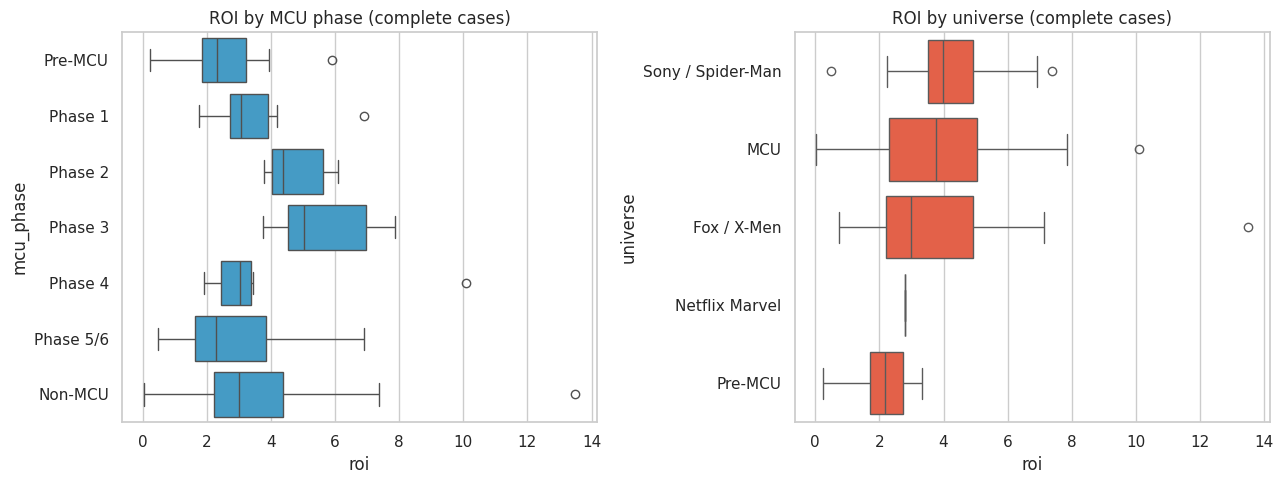

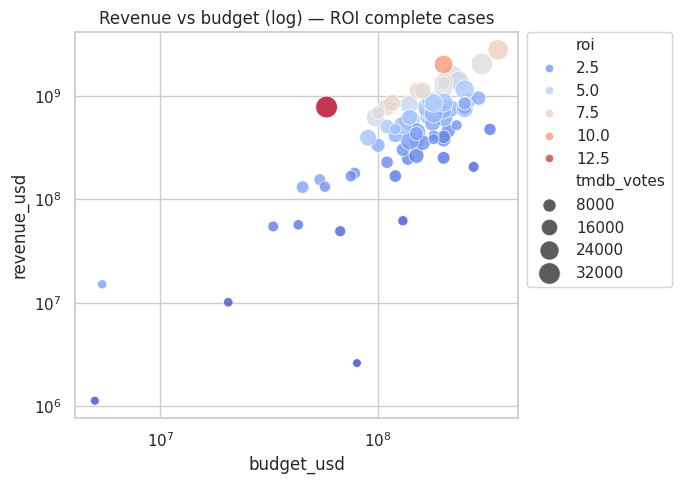

mcu_phase,Non-MCU,Phase 1,Phase 2,Phase 3,Phase 4,Phase 5/6,Pre-MCU
universe,,,,,,,
Fox / X-Men,3.02,NaN,NaN,NaN,NaN,NaN,2.19
MCU,0.95,3.06,4.38,5.03,3.04,2.27,NaN
Netflix Marvel,2.79,NaN,NaN,NaN,NaN,NaN,NaN
Pre-MCU,NaN,NaN,NaN,NaN,NaN,NaN,2.19
Sony / Spider-Man,3.99,NaN,NaN,NaN,NaN,3.99,3.94


In [6]:
econ = df.dropna(subset=["roi"]).copy()
assert (econ["budget_usd"] > 0).all() and (econ["revenue_usd"] > 0).all()
print("ROI complete cases:", len(econ))

phase_order = ["Pre-MCU", "Phase 1", "Phase 2", "Phase 3", "Phase 4", "Phase 5/6", "Non-MCU"]
phase_order = [p for p in phase_order if p in set(econ["mcu_phase"])]

fig, axes = plt.subplots(1, 2, figsize=(13, 5))
sns.boxplot(data=econ, y="mcu_phase", x="roi", order=phase_order, ax=axes[0], color="#30a2da")
axes[0].set_title("ROI by MCU phase (complete cases)")
sns.boxplot(data=econ, y="universe", x="roi",
            order=econ.groupby("universe")["roi"].median().sort_values(ascending=False).index,
            ax=axes[1], color="#fc4f30")
axes[1].set_title("ROI by universe (complete cases)")
plt.tight_layout()
plt.show()

# Budget vs revenue with ROI hue
fig, ax = plt.subplots(figsize=(7, 5))
sns.scatterplot(
    data=econ, x="budget_usd", y="revenue_usd", hue="roi",
    palette="coolwarm", size="tmdb_votes", sizes=(40, 280), alpha=0.8, ax=ax,
)
ax.set_xscale("log")
ax.set_yscale("log")
ax.set_title("Revenue vs budget (log) — ROI complete cases")
ax.legend(bbox_to_anchor=(1.02, 1), loc="upper left", borderaxespad=0)
plt.tight_layout()
plt.show()

pivot = econ.pivot_table(index="universe", columns="mcu_phase", values="roi", aggfunc="median")
display(pivot.round(2))


**Interpretation** <br>
ROI boxes are complete-case only — sparse phases with few budgeted titles will look jumpy. Log budget–revenue scatter shows whether returns scale with spend or whether a few outliers dominate medians.


# **6. Cast Popularity:** <a id="Cast"></a>


,credits,mean_pop,median_order
actor_name,,,
Scarlett Johansson,8,10.53,3.5
Morena Baccarin,3,7.48,2.0
Vin Diesel,5,7.41,4.0
Zendaya,4,6.91,3.0
Tom Holland,7,6.78,0.0
Robert Downey Jr.,9,5.53,0.0
Nicolas Cage,3,5.43,0.0
Tom Hardy,3,5.39,0.0
J.K. Simmons,3,5.36,6.0


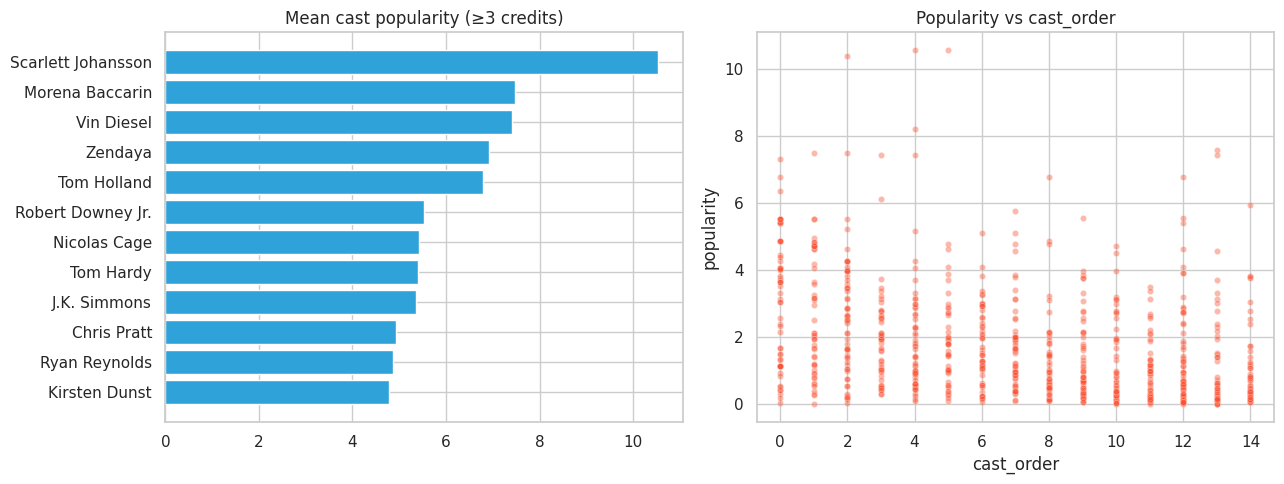

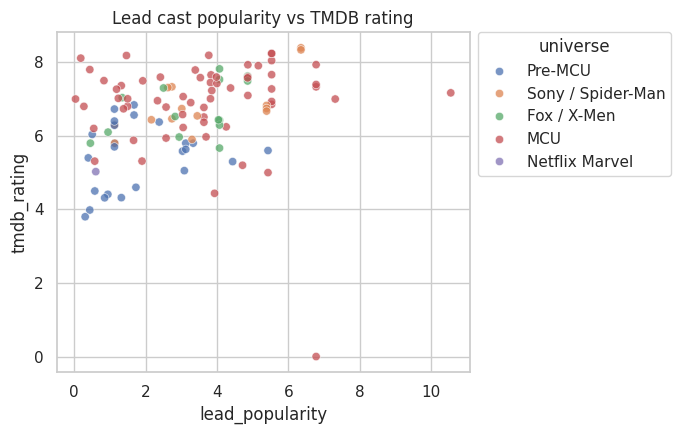

In [7]:
# Top actors by mean TMDB popularity (min 3 credits)
actor_stats = (
    cast.groupby("actor_name")
    .agg(credits=("title", "nunique"), mean_pop=("popularity", "mean"), median_order=("cast_order", "median"))
    .query("credits >= 3")
    .sort_values("mean_pop", ascending=False)
)
display(actor_stats.head(15).round(2))

fig, axes = plt.subplots(1, 2, figsize=(13, 5))
top = actor_stats.head(12).sort_values("mean_pop")
axes[0].barh(top.index, top["mean_pop"], color="#30a2da")
axes[0].set_title("Mean cast popularity (≥3 credits)")
sns.scatterplot(
    data=cast.sample(min(800, len(cast)), random_state=7),
    x="cast_order", y="popularity", alpha=0.4, s=20, ax=axes[1], color="#fc4f30",
)
axes[1].set_title("Popularity vs cast_order")
plt.tight_layout()
plt.show()

# Join lead cast popularity to master (cast_order == 0)
lead = cast.loc[cast["cast_order"] == 0, ["title", "year", "actor_name", "popularity"]].rename(
    columns={"popularity": "lead_popularity", "actor_name": "lead_actor"}
)
mlead = df.merge(lead, on=["title", "year"], how="left")
fig, ax = plt.subplots(figsize=(7, 4.5))
sns.scatterplot(
    data=mlead.dropna(subset=["lead_popularity", "tmdb_rating"]),
    x="lead_popularity", y="tmdb_rating", hue="universe", alpha=0.75, ax=ax,
)
ax.set_title("Lead cast popularity vs TMDB rating")
ax.legend(title="universe", bbox_to_anchor=(1.02, 1), loc="upper left", borderaxespad=0)
plt.tight_layout()
plt.show()


**Interpretation** <br>
Frequent actors with high mean popularity are the franchise anchors. Cast-order vs popularity should decline if billing tracks fame. Lead popularity vs TMDB rating is a soft star-power check — not a causal claim.


# **7. Multivariate Association (RF):** <a id="Association"></a>


Complete cases for RF (tmdb_rating path): 93


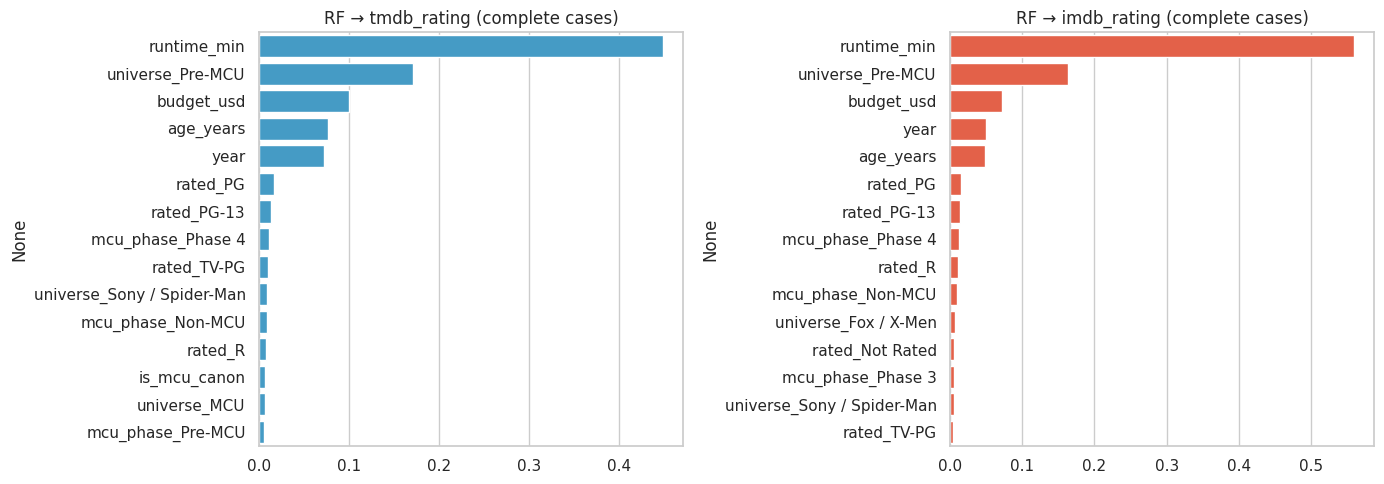

RF in-sample R^2 tmdb: 0.929 n= 93
RF in-sample R^2 imdb: 0.939 n= 89


In [8]:
# RF for tmdb_rating / imdb_rating on complete cases (no revenue leakage into rating if we want "pre-release" feel —
# here we allow budget as scale control; drop revenue/roi as outcome-tied)
base = df.dropna(subset=["tmdb_rating", "year", "runtime_min", "budget_usd", "universe", "mcu_phase", "type"]).copy()
print("Complete cases for RF (tmdb_rating path):", len(base))
assert len(base) >= 30, "too few complete cases for RF"

feature_num = ["year", "runtime_min", "budget_usd", "is_animated", "is_tv_series", "is_mcu_canon", "age_years"]
feature_cat = ["universe", "mcu_phase", "type", "rated"]
# rated may still be null in base — fill only if present enough
if base["rated"].isna().mean() > 0.4:
    feature_cat = ["universe", "mcu_phase", "type"]

X = base[feature_num + feature_cat]
y = base["tmdb_rating"]
pre = ColumnTransformer([
    ("num", "passthrough", feature_num),
    ("cat", OneHotEncoder(handle_unknown="ignore"), feature_cat),
])
pipe = Pipeline([
    ("pre", pre),
    ("rf", RandomForestRegressor(n_estimators=300, max_depth=10, random_state=7, n_jobs=-1)),
])
pipe.fit(X, y)
rf = pipe.named_steps["rf"]
enc = pipe.named_steps["pre"]
names = feature_num + list(enc.named_transformers_["cat"].get_feature_names_out(feature_cat))
imp = pd.Series(rf.feature_importances_, index=names).sort_values(ascending=False).head(15)

# Secondary: imdb_rating complete cases
base_i = df.dropna(subset=["imdb_rating"] + feature_num + feature_cat).copy()
pipe_i = Pipeline([
    ("pre", ColumnTransformer([
        ("num", "passthrough", feature_num),
        ("cat", OneHotEncoder(handle_unknown="ignore"), feature_cat),
    ])),
    ("rf", RandomForestRegressor(n_estimators=300, max_depth=10, random_state=7, n_jobs=-1)),
])
pipe_i.fit(base_i[feature_num + feature_cat], base_i["imdb_rating"])
rf_i = pipe_i.named_steps["rf"]
enc_i = pipe_i.named_steps["pre"]
names_i = feature_num + list(enc_i.named_transformers_["cat"].get_feature_names_out(feature_cat))
imp_i = pd.Series(rf_i.feature_importances_, index=names_i).sort_values(ascending=False).head(15)

fig, axes = plt.subplots(1, 2, figsize=(14, 5))
sns.barplot(x=imp.values, y=imp.index, ax=axes[0], color="#30a2da")
axes[0].set_title("RF → tmdb_rating (complete cases)")
sns.barplot(x=imp_i.values, y=imp_i.index, ax=axes[1], color="#fc4f30")
axes[1].set_title("RF → imdb_rating (complete cases)")
plt.tight_layout()
plt.show()
print("RF in-sample R^2 tmdb:", round(rf.score(enc.transform(X), y), 3), "n=", len(base))
print("RF in-sample R^2 imdb:", round(rf_i.score(enc_i.transform(base_i[feature_num + feature_cat]), base_i["imdb_rating"]), 3),
      "n=", len(base_i))


**Interpretation** <br>
RF is fit only on complete cases and excludes revenue/ROI (outcome-tied to commercial success). Importances are exploratory — with n≪200, treat rankings as fragile.


# **8. What It Means — Working Synthesis:** <a id="Synthesis"></a>

**What the table is:** <br>
A Marvel media master table (161 titles) linked to long-form ratings and cast popularity — with heavy, structured missingness.

**Working takeaways:** <br>
- `production` and `website` are fully empty and were dropped; score/budget fields need parsing and complete-case discipline.
- Ratings sources broadly co-move; IMDb↔TMDB concordance is the densest audience pair.
- ROI on budget×revenue complete cases (~75 titles) is the honest economic slice — phase medians are noisy where n is small.
- Cast popularity highlights franchise anchors; lead popularity vs rating is a weak star-power check.
- RF rating models are small-n exploratory tools, not production predictors.

**Open follow-ups:** <br>
- Within-MCU phase effects on RT after runtime/budget controls.
- Whether collection_name membership predicts ROI above phase baselines.
- Cast-graph centrality vs lead popularity as an alternate star measure.
